In [60]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import ParameterGrid


import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    fbeta_score
)

In [35]:
df = pd.read_csv("../../../data/processed/feature_dataset.csv")

In [36]:
# One hot encoding for age and recording location
df = pd.get_dummies(df, columns=["Age"], drop_first=True)

df = pd.get_dummies(df, columns=["recording_location"], drop_first=True)

df = pd.get_dummies(df, columns=["Murmur"], drop_first=True)

df["Sex"] = df["Sex"].map({
    "Female": 0,
    "Male": 1
})

df["Outcome"] = df["Outcome"].map({
    "Normal": 0,
    "Abnormal": 1
})

print(df.columns.tolist())

['Patient ID', 'Outcome', 'split', 'Sex', 'Height', 'Weight', 'Pregnancy status', 'file', 'Campaign', 'Additional ID', 'rms', 'peak', 'variance', 'mean', 'std', 'skew', 'kurtosis', 'zcr', 'dynamic_range', 'spectral_centroid', 'spectral_bandwidth', 'spectral_rolloff', 'spectral_flatness', 'band_energy_20_50', 'band_energy_50_100', 'band_energy_100_200', 'band_energy_200_400', 'band_energy_400_800', 'mfcc_1_mean', 'mfcc_1_std', 'mfcc_d1_1_mean', 'mfcc_d1_1_std', 'mfcc_d2_1_mean', 'mfcc_d2_1_std', 'mfcc_2_mean', 'mfcc_2_std', 'mfcc_d1_2_mean', 'mfcc_d1_2_std', 'mfcc_d2_2_mean', 'mfcc_d2_2_std', 'mfcc_3_mean', 'mfcc_3_std', 'mfcc_d1_3_mean', 'mfcc_d1_3_std', 'mfcc_d2_3_mean', 'mfcc_d2_3_std', 'mfcc_4_mean', 'mfcc_4_std', 'mfcc_d1_4_mean', 'mfcc_d1_4_std', 'mfcc_d2_4_mean', 'mfcc_d2_4_std', 'mfcc_5_mean', 'mfcc_5_std', 'mfcc_d1_5_mean', 'mfcc_d1_5_std', 'mfcc_d2_5_mean', 'mfcc_d2_5_std', 'mfcc_6_mean', 'mfcc_6_std', 'mfcc_d1_6_mean', 'mfcc_d1_6_std', 'mfcc_d2_6_mean', 'mfcc_d2_6_std', 'mfcc

In [37]:
# -----------------------------
# Split using your predefined split
# -----------------------------
train_df = df[df["split"] == "train"]
val_df   = df[df["split"] == "val"]
test_df  = df[df["split"] == "test"]

In [38]:
# -----------------------------
# Prepare features
# -----------------------------
drop_cols = ["Patient ID", "Outcome", "split", "file", "Campaign", "Additional ID", "Height", "Weight"]

drop_cols = drop_cols + ["rms"]

X_train = train_df.drop(columns=drop_cols)
y_train = train_df["Outcome"]

X_val = val_df.drop(columns=drop_cols)
y_val = val_df["Outcome"]

X_test = test_df.drop(columns=drop_cols)
y_test = test_df["Outcome"]

In [23]:
# Calculate correlation matrix
corr_matrix = X_train.corr()

# Get upper triangle only (avoid duplicate pairs and self-correlation)
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Find highly correlated feature pairs
high_corr = (
    upper.stack()
    .reset_index()
    .rename(columns={
        "level_0": "Feature 1",
        "level_1": "Feature 2",
        0: "Correlation"
    })
)

# Sort by absolute correlation
high_corr["Abs Correlation"] = high_corr["Correlation"].abs()

high_corr = high_corr.sort_values(
    by="Abs Correlation",
    ascending=False
)

# Show correlations above threshold
threshold = 0.9

print(
    high_corr[
        high_corr["Abs Correlation"] >= threshold
    ]
)

               Feature 1          Feature 2  Correlation  Abs Correlation
1082   spectral_centroid   spectral_rolloff     0.960905         0.960905
1202  spectral_bandwidth        mfcc_2_mean    -0.954890         0.954890
9290         mfcc_12_std     mfcc_d1_12_std     0.949410         0.949410
9938         mfcc_13_std     mfcc_d1_13_std     0.949144         0.949144
8642         mfcc_11_std     mfcc_d1_11_std     0.947708         0.947708
207     Pregnancy status    Age_Young adult     0.945380         0.945380
7994         mfcc_10_std     mfcc_d1_10_std     0.943340         0.943340
7346          mfcc_9_std      mfcc_d1_9_std     0.943027         0.943027
1083   spectral_centroid  spectral_flatness     0.937764         0.937764
1189  spectral_bandwidth   spectral_rolloff     0.933680         0.933680
6698          mfcc_8_std      mfcc_d1_8_std     0.925447         0.925447
9292         mfcc_12_std     mfcc_d2_12_std     0.924024         0.924024
7348          mfcc_9_std      mfcc_d2_

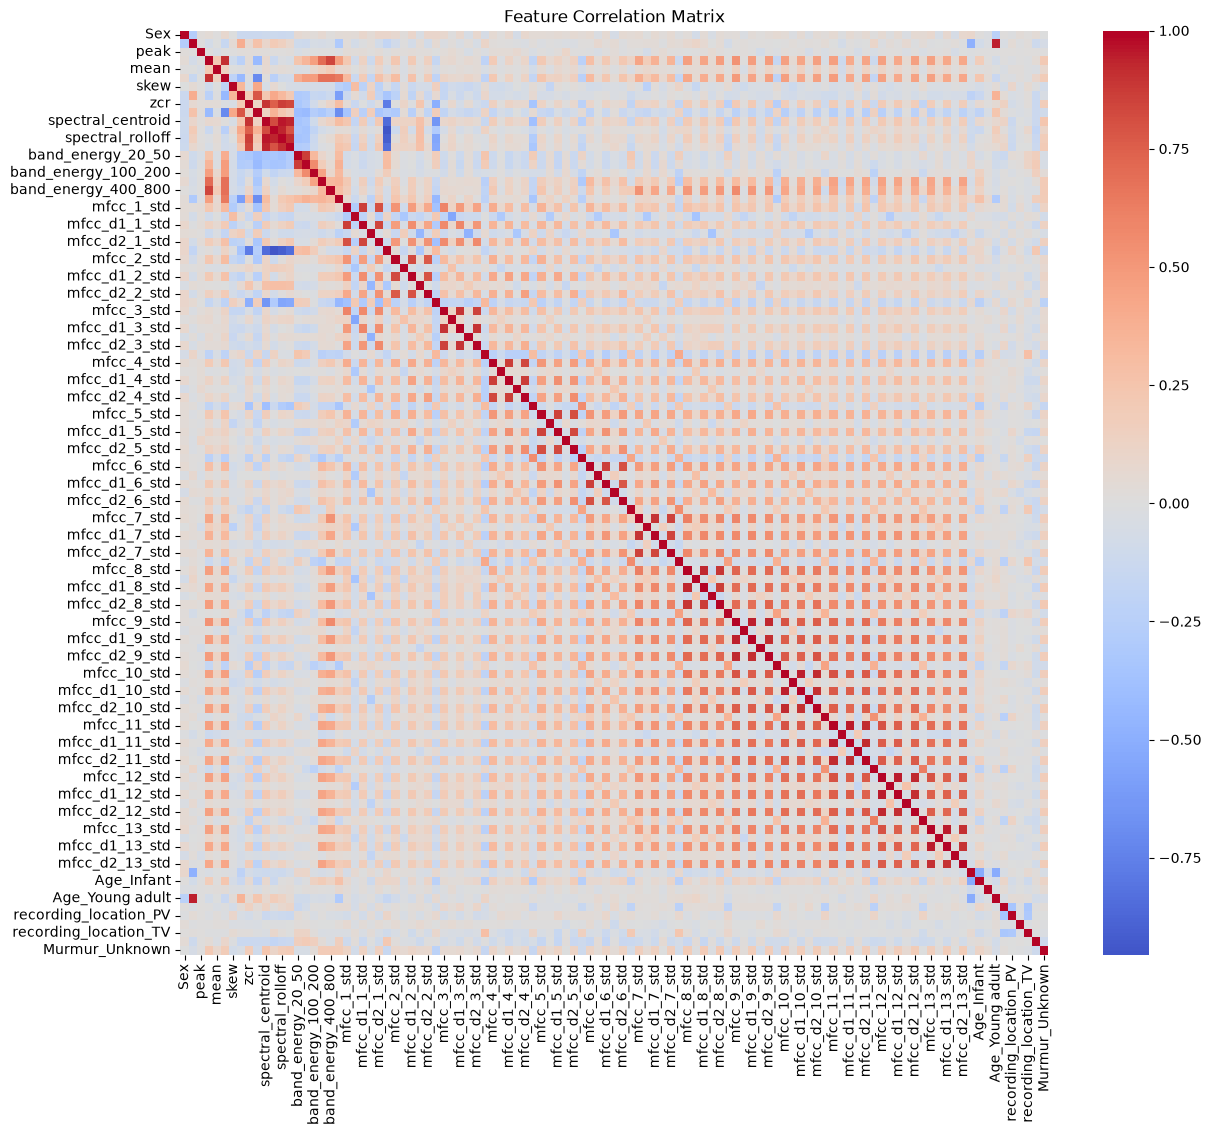

In [24]:
# Plot heatmap of correlation matrix

plt.figure(figsize=(14, 12))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")
plt.show()

In [25]:
# -----------------------------
# Scaling (IMPORTANT for linear models)
# -----------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [ ]:
# -----------------------------
# Models (Manually trying hyperparameters)
# -----------------------------
models = {
    "L2": LogisticRegression(
        penalty="l2",
        C=0.1,
        max_iter=4000
    ),

    "L1": LogisticRegression(
        penalty="l1",
        solver="saga",
        C=0.1,
        max_iter=4000
    ),
    
    "weighted_L1": LogisticRegression(
        penalty="l1",
        solver="saga",
        C=0.1,
        class_weight={
            0: 1,
            1: 2
        },
        max_iter=4000
    ),

    "ElasticNet": LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        C=0.1,
        l1_ratio=0.5,
        max_iter=4000
    )
}

# Feature names after dropping unwanted columns
train_df_dropped = train_df.drop(columns=drop_cols)

# Store results
coefficients = {}

# Train and analyze models
for name, model in models.items():
    model.fit(X_train, y_train)

    coef = pd.Series(
        model.coef_[0],
        index=train_df_dropped.columns
    )

    coefficients[name] = coef

c:\Users\malek\Desktop\Malek\Studium\M.Sc Informatik (TUM)\Semester 2\(CaCOM)\CaCOM-HeartWISE\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\malek\Desktop\Malek\Studium\M.Sc Informatik (TUM)\Semester 2\(CaCOM)\CaCOM-HeartWISE\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 

In [27]:
# Features selected by each model
for name, coef in coefficients.items():
    print(f"\n{name} selected features:")
    print(coef[coef != 0].sort_values(key=abs, ascending=False))


L2 selected features:
Murmur_Present         0.790857
mfcc_1_std             0.299610
mfcc_d2_9_std         -0.266168
band_energy_100_200    0.238218
mfcc_d2_1_std         -0.222831
                         ...   
mfcc_d2_7_mean         0.006662
mfcc_d1_7_mean         0.005460
mfcc_d1_8_mean         0.005324
mfcc_13_mean           0.002319
mfcc_d2_3_mean         0.001422
Length: 107, dtype: float64

L1 selected features:
Murmur_Present            0.764850
Pregnancy status         -0.143685
Age_Young adult          -0.134559
Murmur_Unknown            0.118677
mfcc_8_mean              -0.112607
mfcc_d2_1_std            -0.104419
mfcc_d2_1_mean           -0.103451
mfcc_12_mean              0.099019
mfcc_7_mean              -0.098529
band_energy_100_200       0.098273
mfcc_d2_9_std            -0.088728
recording_location_Phc    0.083946
mfcc_3_mean              -0.079615
mfcc_d1_12_mean           0.077906
Age_Child                -0.075666
mfcc_d2_2_mean           -0.066286
mfcc_d1_11_std

In [28]:
summary = pd.DataFrame({
    name: {
        "selected_features": (coef != 0).sum(),
        "zero_coefficients": (coef == 0).sum()
    }
    for name, coef in coefficients.items()
}).T

print(summary)

             selected_features  zero_coefficients
L2                         107                  0
L1                          54                 53
weighted_L1                 65                 42
ElasticNet                  75                 32


In [32]:
results = []

for name, model in models.items():
    # Predictions
    y_pred = model.predict(X_test)

    # Probabilities for ROC-AUC
    y_prob = model.predict_proba(X_test)[:, 1]

    # Coefficients
    coef = pd.Series(
        model.coef_[0],
        index=train_df_dropped.columns
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "Features": (coef != 0).sum()
    })

results_df = pd.DataFrame(results)

print(results_df.sort_values("ROC-AUC", ascending=False))

         Model  Accuracy  Precision    Recall        F1   ROC-AUC  Features
0           L2  0.670886   0.731429  0.540084  0.621359  0.703110       107
1           L1  0.675105   0.761006  0.510549  0.611111  0.697751        54
3   ElasticNet  0.662447   0.730539  0.514768  0.603960  0.697342        75
2  weighted_L1  0.561181   0.537468  0.877637  0.666667  0.693016        62


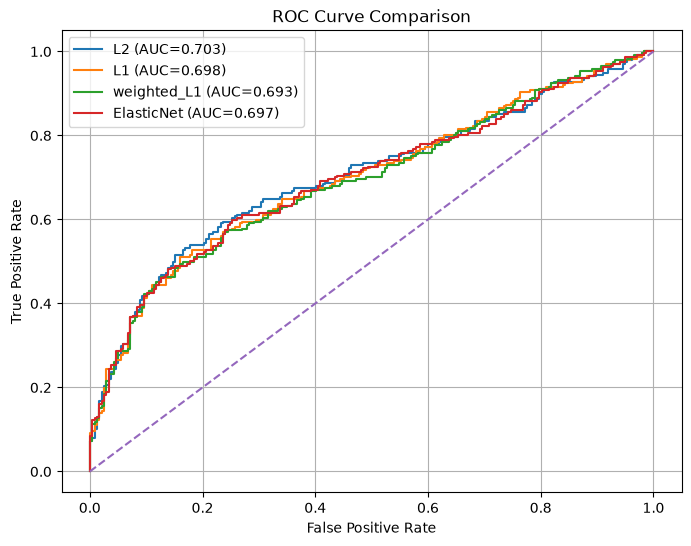

In [33]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(8,6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc:.3f})"
    )

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid()
plt.show()

In [ ]:
param_grid = {
    "penalty": [
        "l1",
        "l2",
        "elasticnet"
    ],
    "C": [
        1e-4, 
        1e-3,
        1e-2,
        1e-1,
        1,
        10,
        100
    ],
    "l1_ratio": [
        0.1,
        0.25,
        0.5,
        0.75,
        0.9
    ],
    "class_weight": [
        None,
        "balanced",
        {0:1, 1:2},
        {0:1, 1:3},
        {0:1,1:5},
        {0:1,1:10}
    ]
}

$F2 = 5 × \frac{Precision × Recall}{(4 × Precision) + Recall}$

* Prioritizing Recall: The F2 score is ideal for situations where missing a positive case (a false negative) carries a massive penalty compared to falsely flagging a negative case (a false positive).
* Use Cases: It is highly recommended in medical diagnoses (where failing to catch an illness is dangerous) and fraud detection (where missing a fraudulent transaction is costly).

In [80]:
import warnings
warnings.filterwarnings("ignore")

best_model = None
best_params = None
best_threshold = None

best_f2 = -1
best_recall = 0
best_precision = 0

min_precision = 0.5

for params in ParameterGrid(param_grid):

    params = params.copy()

    # Handle valid solver/penalty combinations
    if params["penalty"] == "elasticnet":
        solver = "saga"

    elif params["penalty"] == "l1":
        solver = "saga"
        params["l1_ratio"] = None

    else:  # l2
        solver = "lbfgs"
        params["l1_ratio"] = None

    print("\nTesting parameters:")
    print(params)

    model = LogisticRegression(
        penalty=params["penalty"],
        C=params["C"],
        solver=solver,
        class_weight=params["class_weight"],
        l1_ratio=params["l1_ratio"],
        max_iter=4000
    )

    model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_val)[:, 1]

    for threshold in np.arange(0.05, 0.95, 0.01):

        y_pred = (y_prob >= threshold).astype(int)

        precision = precision_score(
            y_val,
            y_pred,
            zero_division=0
        )

        # Ignore models that don't meet the precision requirement
        if precision < min_precision:
            continue

        recall = recall_score(y_val, y_pred)

        f2 = fbeta_score(
            y_val,
            y_pred,
            beta=2,
            zero_division=0
        )

        if f2 > best_f2:

            print("New best model found!")
            print(f"F2:        {f2:.3f}")
            print(f"Precision: {precision:.3f}")
            print(f"Recall:    {recall:.3f}")
            print(f"Threshold: {threshold:.2f}")

            best_f2 = f2
            best_recall = recall
            best_precision = precision

            best_threshold = threshold
            best_model = model
            best_params = params.copy()

print("\n==========================")
print("FINAL BEST MODEL")
print("==========================")
print("Parameters:")
print(best_params)

print(f"Threshold: {best_threshold:.2f}")
print(f"F2 Score:  {best_f2:.3f}")
print(f"Precision: {best_precision:.3f}")
print(f"Recall:    {best_recall:.3f}")


Testing parameters:
{'C': 0.001, 'class_weight': None, 'l1_ratio': None, 'penalty': 'l1'}
New best model found!
F2:        0.776
Precision: 0.512
Recall:    0.890
Threshold: 0.42

Testing parameters:
{'C': 0.001, 'class_weight': None, 'l1_ratio': None, 'penalty': 'l2'}
New best model found!
F2:        0.791
Precision: 0.504
Recall:    0.922
Threshold: 0.36

Testing parameters:
{'C': 0.001, 'class_weight': None, 'l1_ratio': 0.25, 'penalty': 'elasticnet'}
New best model found!
F2:        0.795
Precision: 0.501
Recall:    0.932
Threshold: 0.39

Testing parameters:
{'C': 0.001, 'class_weight': None, 'l1_ratio': None, 'penalty': 'l1'}

Testing parameters:
{'C': 0.001, 'class_weight': None, 'l1_ratio': None, 'penalty': 'l2'}

Testing parameters:
{'C': 0.001, 'class_weight': None, 'l1_ratio': 0.5, 'penalty': 'elasticnet'}

Testing parameters:
{'C': 0.001, 'class_weight': None, 'l1_ratio': None, 'penalty': 'l1'}

Testing parameters:
{'C': 0.001, 'class_weight': None, 'l1_ratio': None, 'penalt

In [81]:
print("\n==========================")
print("FINAL BEST MODEL")
print("==========================")
print("Parameters:")
print(best_params)
print(f"Threshold: {best_threshold:.2f}")
print(f"Precision: {best_precision:.3f}")
print(f"Recall: {best_recall:.3f}")


FINAL BEST MODEL
Parameters:
{'C': 10, 'class_weight': {0: 1, 1: 2}, 'l1_ratio': None, 'penalty': 'l2'}
Threshold: 0.42
Precision: 0.516
Recall: 0.968


In [82]:
# Retrain best model on train and validation data

X_trainval = pd.concat(
    [X_train, X_val],
    axis=0,
    ignore_index=True
)

y_trainval = pd.concat(
    [y_train, y_val],
    axis=0,
    ignore_index=True
)

best_lr_model = LogisticRegression(
    penalty="l2",
    C=10,
    class_weight={0: 1, 1: 2},
    max_iter=4000
)

best_lr_model.fit(
    X_trainval,
    y_trainval
)

threshold = 0.42

y_prob = best_lr_model.predict_proba(X_test)[:, 1]

y_pred = (y_prob >= threshold).astype(int)

In [ ]:
# Benchmarking metrics on Test Set
# DO NOT FINE TUNE MODEL BASED ON THESE RESULTS
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F2:", fbeta_score(
                y_test,
                y_pred,
                beta=2,
                zero_division=0
            )
    )
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print(confusion_matrix(y_test, y_pred))

Precision: 0.5216346153846154
Recall: 0.9156118143459916
F2: 0.7954545454545454
ROC-AUC: 0.6925528316331072
[[ 38 199]
 [ 20 217]]


### Precision Recall Curve

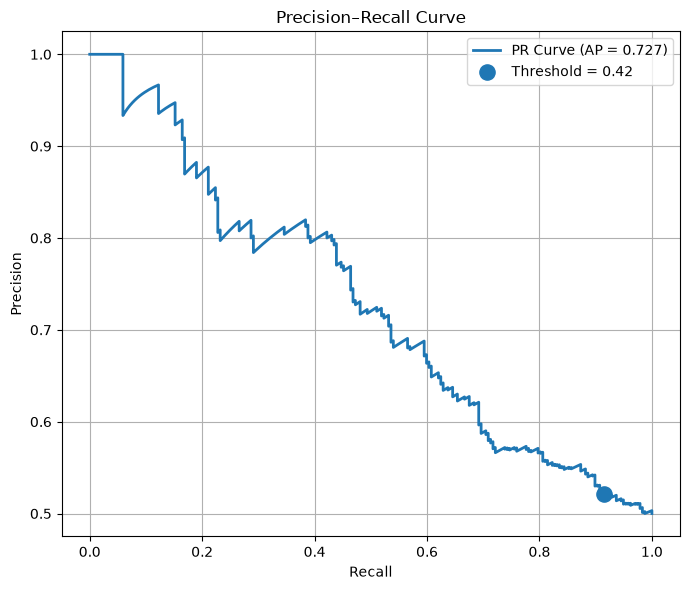

In [84]:
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    precision_score,
    recall_score
)

# Probabilities
y_prob = best_lr_model.predict_proba(X_test)[:, 1]

# PR curve
precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

ap = average_precision_score(
    y_test,
    y_prob
)

# Chosen operating point
y_pred = (y_prob >= best_threshold).astype(int)

selected_precision = precision_score(
    y_test,
    y_pred
)

selected_recall = recall_score(
    y_test,
    y_pred
)

plt.figure(figsize=(7,6))

plt.plot(
    recall,
    precision,
    linewidth=2,
    label=f"PR Curve (AP = {ap:.3f})"
)

plt.scatter(
    selected_recall,
    selected_precision,
    s=120,
    marker="o",
    label=f"Threshold = {best_threshold:.2f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Confusion Matrix

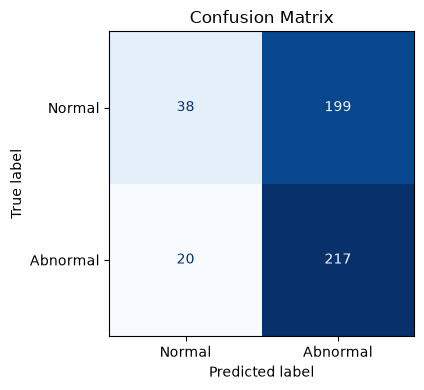

In [86]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = (
    y_prob >= best_threshold
).astype(int)

cm = confusion_matrix(
    y_test,
    y_pred
)

fig, ax = plt.subplots(figsize=(6,4))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Abnormal"]
)

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False
)

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()